In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cell 1: imports + load CSV
import pandas as pd
import numpy as np
from pathlib import Path

candidates = [Path("final_model_data.csv"), Path("../final_model_data.csv")]
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("final_model_data.csv not found in current or parent folder.")

df = pd.read_csv(csv_path, low_memory=False)
print(f"Loaded: {csv_path.resolve()} | Shape: {df.shape}")
df.head()


Loaded: /Users/prithabera/data-science-group-project/final_model_data.csv | Shape: (52608, 48)


,datetime,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,...,Temp_Eng_London,Solar_Eng_London,Temp_Eng_South_Kent,Solar_Eng_South_Kent,Temp_Eng_South_Hampshire,Solar_Eng_South_Hampshire,Temp_Eng_South_Cornwall,Solar_Eng_South_Cornwall,Temp_Eng_South_Bristol,Solar_Eng_South_Bristol
0,2020-01-01 00:00:00,26630.5,27418.5,24107.0,1046.5,6465.0,0.0,13040.0,0.0,16.0,...,4.0,0.0,3.5,0.0,4.6,0.0,7.5,0.0,6.2,0.0
1,2020-01-01 01:00:00,26161.5,26837.5,23717.5,1026.5,6465.0,0.0,13040.0,0.0,16.5,...,2.0,0.0,1.3,0.0,4.6,0.0,7.3,0.0,5.4,0.0
2,2020-01-01 02:00:00,24771.5,25683.0,22500.0,993.0,6465.0,0.0,13040.0,0.0,173.5,...,2.0,0.0,1.6,0.0,4.6,0.0,7.3,0.0,4.2,0.0
3,2020-01-01 03:00:00,23382.5,24899.5,21157.0,965.5,6465.0,0.0,13040.0,0.0,843.0,...,2.5,0.0,3.0,0.0,3.6,0.0,7.9,0.0,4.7,0.0
4,2020-01-01 04:00:00,22429.5,23860.0,20393.0,995.5,6465.0,0.0,13040.0,0.0,711.5,...,3.3,0.0,3.7,0.0,3.5,0.0,8.1,0.0,4.9,0.0


In [3]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 48 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   datetime                     52608 non-null  object 
 1   ND                           52608 non-null  float64
 2   TSD                          52608 non-null  float64
 3   ENGLAND_WALES_DEMAND         52608 non-null  float64
 4   EMBEDDED_WIND_GENERATION     52608 non-null  float64
 5   EMBEDDED_WIND_CAPACITY       52608 non-null  float64
 6   EMBEDDED_SOLAR_GENERATION    52608 non-null  float64
 7   EMBEDDED_SOLAR_CAPACITY      52608 non-null  float64
 8   NON_BM_STOR                  52608 non-null  float64
 9   PUMP_STORAGE_PUMPING         52608 non-null  float64
 10  NET_IMPORTS                  52608 non-null  float64
 11  SCOTTISH_TRANSFER            52608 non-null  float64
 12  Temp_Scot_Highlands          52608 non-null  float64
 13  Wind10m_Scot_Hig

In [4]:
df.describe()

,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,NET_IMPORTS,...,Temp_Eng_London,Solar_Eng_London,Temp_Eng_South_Kent,Solar_Eng_South_Kent,Temp_Eng_South_Hampshire,Solar_Eng_South_Hampshire,Temp_Eng_South_Cornwall,Solar_Eng_South_Cornwall,Temp_Eng_South_Bristol,Solar_Eng_South_Bristol
count,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.00000,52608.000000,...,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000
mean,26770.351914,28737.705686,24532.497928,1887.057073,6549.762565,1578.623242,15957.783569,0.418596,192.70072,2373.489674,...,11.687532,129.313850,11.225285,133.449456,11.195497,132.190522,11.505096,134.336698,11.047687,130.382984
std,6204.036984,5919.255561,5679.619570,1212.467655,38.641463,2476.383781,2637.639416,9.629662,358.80173,2797.418146,...,6.233033,198.246635,5.985446,203.573706,5.858029,202.669453,4.472282,207.144118,5.608837,201.907688
min,12955.000000,15510.500000,12158.000000,126.500000,6465.000000,0.000000,13040.000000,0.000000,0.00000,-7877.500000,...,-10.300000,0.000000,-8.500000,0.000000,-5.200000,0.000000,-4.100000,0.000000,-6.200000,0.000000
25%,21913.500000,24247.000000,20078.500000,912.000000,6527.000000,0.000000,13724.375000,0.000000,7.00000,713.875000,...,7.300000,0.000000,7.100000,0.000000,7.200000,0.000000,8.600000,0.000000,7.200000,0.000000
50%,25880.000000,27808.500000,23681.750000,1556.500000,6545.000000,22.500000,15036.750000,0.000000,11.00000,2866.750000,...,11.400000,6.000000,11.000000,6.000000,11.000000,6.000000,11.400000,6.000000,10.900000,5.000000
75%,30692.625000,32379.750000,28132.625000,2624.500000,6562.000000,2520.625000,17812.375000,0.000000,160.00000,4274.500000,...,15.900000,203.000000,15.400000,211.000000,15.200000,208.000000,14.700000,207.000000,14.900000,200.000000
max,46419.000000,47654.500000,42327.000000,5941.000000,6622.000000,13951.000000,21504.000000,481.000000,1853.00000,9209.000000,...,37.900000,881.000000,36.600000,910.000000,33.900000,901.000000,30.400000,923.000000,33.100000,897.000000


In [5]:
df.columns

Index(['datetime', 'ND', 'TSD', 'ENGLAND_WALES_DEMAND',
       'EMBEDDED_WIND_GENERATION', 'EMBEDDED_WIND_CAPACITY',
       'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR',
       'PUMP_STORAGE_PUMPING', 'NET_IMPORTS', 'SCOTTISH_TRANSFER',
       'Temp_Scot_Highlands', 'Wind10m_Scot_Highlands',
       'Temp_Scot_Aberdeenshire', 'Wind10m_Scot_Aberdeenshire',
       'Temp_Scot_Glasgow_West', 'Temp_Scot_Edinburgh_East',
       'Temp_Scot_Borders', 'Wind10m_Scot_Borders', 'Temp_Wales_North_Gwynedd',
       'Wind10m_Wales_North_Gwynedd', 'Temp_Wales_South_Cardiff',
       'Temp_Eng_North_Tyne', 'Temp_Eng_North_Cumbria',
       'Wind10m_Eng_North_Cumbria', 'Temp_Eng_Yorkshire',
       'Wind10m_Eng_Yorkshire', 'Temp_Eng_Manchester',
       'Temp_Eng_West_Midlands', 'Temp_Eng_East_Midlands',
       'Solar_Eng_East_Midlands', 'Temp_Eng_East_Norfolk',
       'Wind10m_Eng_East_Norfolk', 'Solar_Eng_East_Norfolk',
       'Temp_Eng_East_Suffolk', 'Wind10m_Eng_East_Suffolk',
   

In [7]:
def outlier_report_iqr(df, cols=None, k=1.5):
    if cols is None:
        cols = df.select_dtypes(include="number").columns.tolist()

    rows = []
    for c in cols:
        x = df[c].dropna()
        if len(x) < 10:
            continue

        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            rows.append([c, len(x), 0, 0.0, q1, q3, np.nan, np.nan])
            continue

        lo = q1 - k * iqr
        hi = q3 + k * iqr
        n_out = int(((df[c] < lo) | (df[c] > hi)).sum())
        pct = 100 * n_out / len(df)
        rows.append([c, len(x), n_out, pct, q1, q3, lo, hi])

    rep = pd.DataFrame(
        rows,
        columns=["col", "non_null", "outliers", "outlier_%", "q1", "q3", "lower", "upper"]
    ).sort_values("outliers", ascending=False)

    return rep

report = outlier_report_iqr(df)   # or energy_df / final_model_df
display(report)                 # top 20 columns with most outliers

,col,non_null,outliers,outlier_%,q1,q3,lower,upper
8,PUMP_STORAGE_PUMPING,52608,9829,18.683470,7.000,160.000,-222.5000,389.5000
4,EMBEDDED_WIND_CAPACITY,52608,4906,9.325578,6527.000,6562.000,6474.5000,6614.5000
44,Solar_Eng_South_Cornwall,52608,4460,8.477798,0.000,207.000,-310.5000,517.5000
46,Solar_Eng_South_Bristol,52608,4441,8.441682,0.000,200.000,-300.0000,500.0000
30,Solar_Eng_East_Midlands,52608,4349,8.266804,0.000,187.000,-280.5000,467.5000
33,Solar_Eng_East_Norfolk,52608,4329,8.228786,0.000,199.000,-298.5000,497.5000
38,Solar_Eng_London,52608,4076,7.747871,0.000,203.000,-304.5000,507.5000
36,Solar_Eng_East_Suffolk,52608,4051,7.700350,0.000,212.000,-318.0000,530.0000
40,Solar_Eng_South_Kent,52608,4017,7.635721,0.000,211.000,-316.5000,527.5000
42,Solar_Eng_South_Hampshire,52608,3996,7.595803,0.000,208.000,-312.0000,520.0000


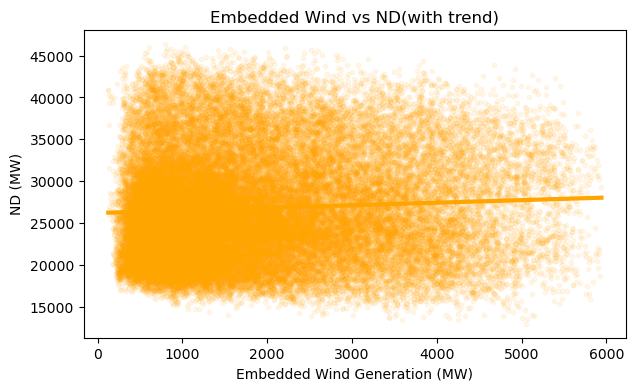

In [12]:

plot_df = df[["EMBEDDED_WIND_GENERATION","ND"]].dropna()
#plot_df = plot_df.sample(30000, random_state=42)

plt.figure(figsize=(7,4))
sns.regplot(
    data=plot_df,
    x="EMBEDDED_WIND_GENERATION",
    y="ND",
    scatter_kws={"alpha":0.08, "s":10},
    color="orange",
    line_kws={"linewidth":3}
)
plt.title("Embedded Wind vs ND(with trend)")
plt.xlabel("Embedded Wind Generation (MW)")
plt.ylabel("ND (MW)")
# plt.grid(True, alpha=0.3, color="purple)
plt.show()


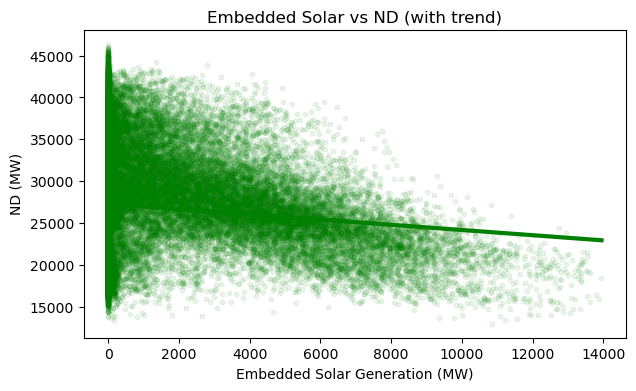

In [14]:
plot_df = df[["EMBEDDED_SOLAR_GENERATION","ND"]].dropna()
#plot_df = plot_df.sample(30000, random_state=42)

plt.figure(figsize=(7,4))
sns.regplot(
    data=plot_df,
    x="EMBEDDED_SOLAR_GENERATION",
    y="ND",
    scatter_kws={"alpha":0.08, "s":10},
    color="green",
    line_kws={"linewidth":3}
)
plt.title("Embedded Solar vs ND (with trend)")
plt.xlabel("Embedded Solar Generation (MW)")
plt.ylabel("ND (MW)")
#plt.grid(True, alpha=0.3)
plt.show()



/var/folders/z_/pzb1cnsj4fq6qjgxkn8w08kh0000gn/T/ipykernel_1997/7385606.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_nd = tmp.groupby(bins)["ND"].mean()
/var/folders/z_/pzb1cnsj4fq6qjgxkn8w08kh0000gn/T/ipykernel_1997/7385606.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_nd = tmp.groupby(bins)["ND"].mean()
/var/folders/z_/pzb1cnsj4fq6qjgxkn8w08kh0000gn/T/ipykernel_1997/7385606.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future def

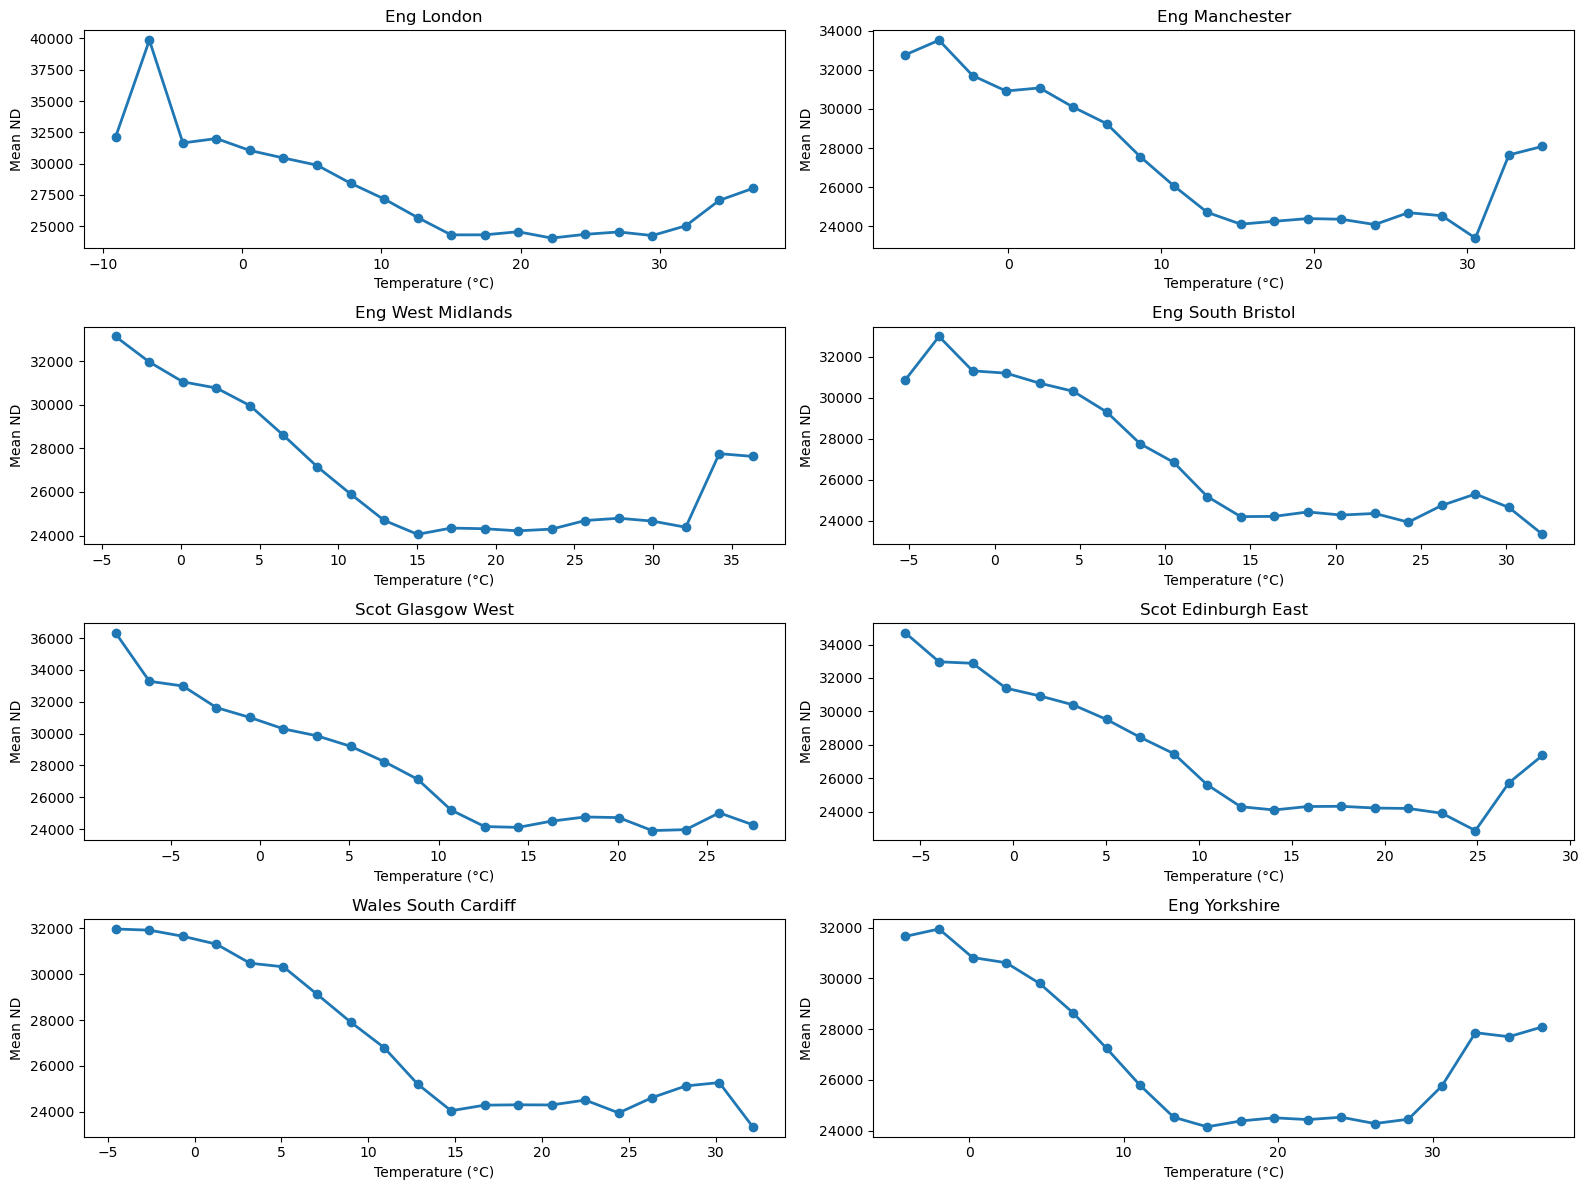

In [15]:


major_temp_cols = [
    "Temp_Eng_London",
    "Temp_Eng_Manchester",
    "Temp_Eng_West_Midlands",
    "Temp_Eng_South_Bristol",
    "Temp_Scot_Glasgow_West",
    "Temp_Scot_Edinburgh_East",
    "Temp_Wales_South_Cardiff",
    "Temp_Eng_Yorkshire"
]

major_temp_cols = [c for c in major_temp_cols if c in df.columns]

plt.figure(figsize=(16, 12))

for i, col in enumerate(major_temp_cols, 1):
    plt.subplot(4, 2, i)

    tmp = df[[col, "ND"]].dropna()

    # bin temperatures (change bins=20 if you want smoother/rougher)
    bins = pd.cut(tmp[col], bins=20)
    mean_nd = tmp.groupby(bins)["ND"].mean()

    # use bin midpoints for x-axis
    x = [b.mid for b in mean_nd.index]

    plt.plot(x, mean_nd.values, marker="o", linewidth=2)
    plt.title(col.replace("Temp_", "").replace("_", " "))
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Mean ND")
    #plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Across all major regions, NET_DEMAND increases as temperature decreases, confirming heating-driven demand. The temperature–demand 
# relationship is consistent but varies in strength by region (different slopes), which motivates using regional weather features instead 
# of a single national weather value.

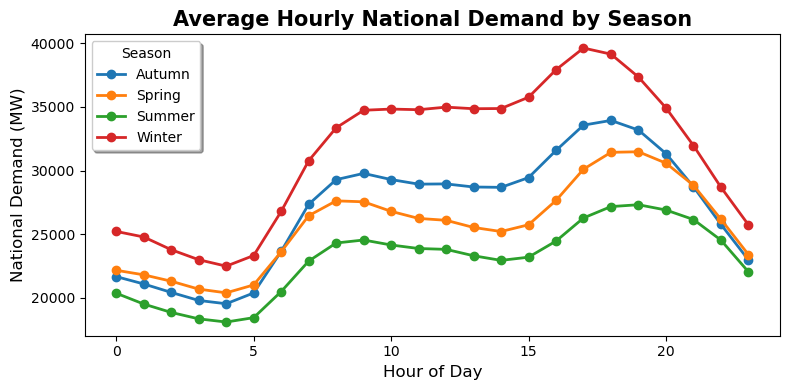

In [20]:

TARGET = "ND"

df_season = df.copy()
df_season["datetime"] = pd.to_datetime(df_season["datetime"], errors='coerce')
df_season = df_season.dropna(subset=["datetime"])

# 2. Extract Hour and Month
df_season["hour"] = df_season["datetime"].dt.hour
df_season["month"] = df_season["datetime"].dt.month

# 3. Create a function to map Months to standard Meteorological Seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

# Apply the function to create a new 'season' column
df_season["season"] = df_season["month"].apply(get_season)

# 4. Group data to find AVERAGE demand by Season and Hour of the Day
grouped_season = df_season.groupby(["season", "hour"])[TARGET].mean().reset_index()

# ==========================================
# VISUALIZATION SETUP
# ==========================================
plt.figure(figsize=(8, 4))

# Define exact colors to match your uploaded reference image
season_colors = {
    'Autumn': '#1f77b4', # Blue
    'Spring': '#ff7f0e', # Orange
    'Summer': '#2ca02c', # Green
    'Winter': '#d62728'  # Red
}

# Plot each season as a line with circular markers ('o')
for season in ['Autumn', 'Spring', 'Summer', 'Winter']:
    season_data = grouped_season[grouped_season["season"] == season]
    
    plt.plot(season_data["hour"], 
             season_data[TARGET], 
             label=season, 
             marker='o',          # Adds the dots on each hour
             linewidth=2,
             color=season_colors[season])

# ==========================================
# AXIS & LABELS SETUP
# ==========================================
plt.title("Average Hourly National Demand by Season", fontsize=15, fontweight='bold')
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("National Demand (MW)", fontsize=12)

# Set x-ticks to match the reference (0, 5, 10, 15, 20)
plt.xticks(range(0, 25, 5))

# Add Legend in the top left
plt.legend(title="Season", loc="upper left", shadow=True)

plt.tight_layout()
plt.show()

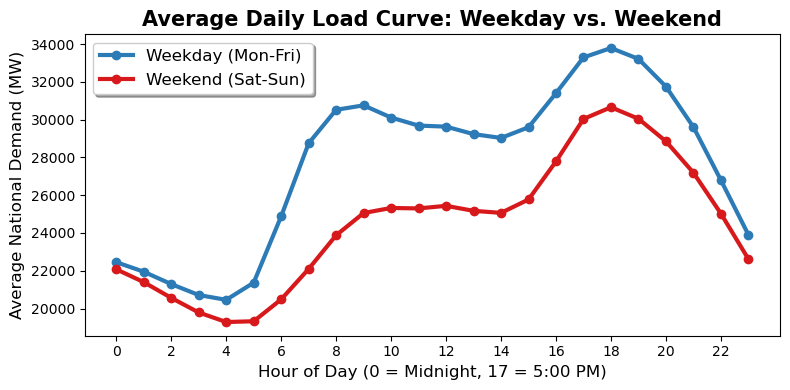

In [26]:

TARGET = "ND"

# 1. Create a fresh copy and ensure datetime is safe
df_daytype = df.copy()
df_daytype["datetime"] = pd.to_datetime(df_daytype["datetime"], errors='coerce')
df_daytype = df_daytype.dropna(subset=["datetime"])

# 2. Extract needed time components
df_daytype["hour"] = df_daytype["datetime"].dt.hour
df_daytype["dayofweek"] = df_daytype["datetime"].dt.dayofweek

# 3. Create a 'Day Type' column (0-4 are Weekdays, 5-6 are Weekends)
df_daytype["Day Type"] = df_daytype["dayofweek"].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# 4. Group by Day Type and Hour to get the average demand
grouped_daytype = df_daytype.groupby(["Day Type", "hour"])[TARGET].mean().reset_index()


plt.figure(figsize=(8, 4))

# Plot Weekday
weekday_data = grouped_daytype[grouped_daytype["Day Type"] == 'Weekday']
plt.plot(weekday_data["hour"], 
         weekday_data[TARGET], 
         label='Weekday (Mon-Fri)', 
         color='#2c7bb6', # Professional Blue
         linewidth=3, 
         marker='o')

# Plot Weekend
weekend_data = grouped_daytype[grouped_daytype["Day Type"] == 'Weekend']
plt.plot(weekend_data["hour"], 
         weekend_data[TARGET], 
         label='Weekend (Sat-Sun)', 
         color='#d7191c', # High-Contrast Red
         linewidth=3, 
         marker='o')

# ==========================================
plt.title("Average Daily Load Curve: Weekday vs. Weekend", fontsize=15, fontweight='bold')
plt.xlabel("Hour of Day (0 = Midnight, 17 = 5:00 PM)", fontsize=12)
plt.ylabel("Average National Demand (MW)", fontsize=12)

# Show every 2 hours on the x-axis for clean reading
plt.xticks(range(0, 24, 2))


plt.legend(fontsize=12, shadow=True)

plt.tight_layout()
plt.show()

In [27]:
TARGET = "ND"   # change to "ND" or "TSD" if needed

df["ND_lag_24"] = df[TARGET].shift(24)   # 1 Day
df["ND_lag_48"] = df[TARGET].shift(48)   # 2 Days
df["ND_lag_72"] = df[TARGET].shift(72)   # 3 Days

# Medium-Term Lags (Weeks)
df["ND_lag_168"] = df[TARGET].shift(168) # 1 Week
df["ND_lag_336"] = df[TARGET].shift(336) # 2 Weeks

# Long-Term Lags (Perfectly aligned by exactly 4 weeks and 52 weeks)
df["ND_lag_672"] = df[TARGET].shift(672)   # Exactly 4 weeks
df["ND_lag_8736"] = df[TARGET].shift(8736) # Exactly 52 weeks

## Why we use Lag-48 and Lag-336

Electricity demand follows strong routines: people wake up, work, cook, and sleep at similar times every day, and weekdays look different from weekends.  
So the demand **at this exact half-hour** is usually close to the demand at the **same half-hour yesterday** and the **same half-hour last week**.

That’s why we add:
- **Lag-48** = demand **24 hours ago** (48 half-hours)
- **Lag-336** = demand **7 days ago** (336 half-hours)

These lag variables act as a strong baseline signal and help models (Linear/Ridge, Random Forest, XGBoost, LSTM) learn the main daily/weekly rhythm, while weather and other features explain the remaining variation (e.g., cold spells, low wind periods, unusual events).


In [30]:
TARGET = "ND"   
H = 24            

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # The formula: mean of |(Actual - Forecast) / Actual| * 100
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# true value we want to predict (tomorrow)
y_true = df[TARGET].shift(-H)

# baseline prediction: tomorrow equals today (exactly 24 hours ago)
y_pred = df[TARGET]

# remove NaNs created by shifting
mask = y_true.notna()
y_true = y_true[mask]
y_pred = y_pred[mask]

# metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("📈 BASELINE MODEL (Naive Forecast: Tomorrow = Today)")
print("-" * 50)
print("RMSE:", round(rmse, 2))
print("MAE :", round(mae, 2))
print("R2  :", round(r2, 3))

# ---> THE FIX: Using the correct variables <---
MAPE = mean_absolute_percentage_error(y_true, y_pred)
print("MAPE:", round(MAPE, 2), "%")

📈 BASELINE MODEL (Naive Forecast: Tomorrow = Today)
--------------------------------------------------
RMSE: 2574.8
MAE : 1836.44
R2  : 0.828
MAPE: 7.04 %


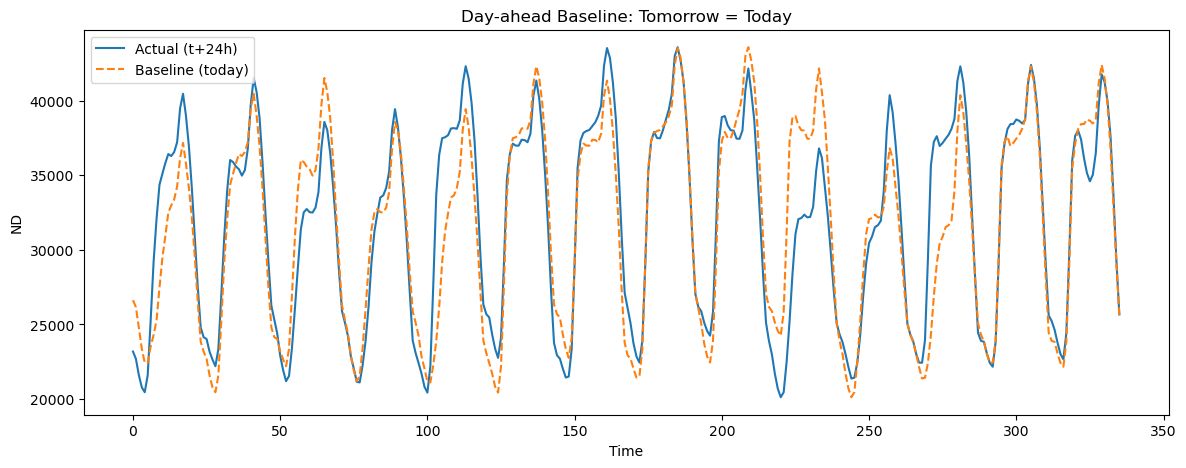

In [32]:
# plot first 7 days (optional)
n = 48 * 7
plt.figure(figsize=(14,5))
plt.plot(y_true.index[:n], y_true.iloc[:n], label="Actual (t+24h)")
plt.plot(y_pred.index[:n], y_pred.iloc[:n], label="Baseline (today)", linestyle="--")
plt.title("Day-ahead Baseline: Tomorrow = Today")
plt.xlabel("Time")
plt.ylabel(TARGET)
plt.legend()
plt.show()